# 4. Modelado con PySpark

Entrenamos los mismos 6 modelos sobre la misma partición 80/20 (`data/split_assignment.parquet`) y las mismas variables de la sección 2.3, usando `pyspark.ml.tuning.CrossValidator` junto con `ParamGridBuilder` (`numFolds=3`, `BinaryClassificationEvaluator(metricName=\"areaUnderROC\")`).

Usamos la misma configuración reducida de Spark que en el preprocesamiento (sección 2.3): `driver.memory=4g`, `executor.memory=4g`, `shuffle.partitions=8` y `default.parallelism=8`, en vez de los 8g+8g y 400 particiones que pedía el enunciado, porque esta máquina tiene 7,8 GB de RAM y 2 núcleos reales. Es la misma máquina física que usamos para scikit-learn, así que la comparación de tiempos entre los dos entornos es justa.

Usamos `CrossValidator(parallelism=1)`, es decir que cada combinación de pliegue e hiperparámetro se corre de forma secuencial, nunca en paralelo. En un clúster con muchos núcleos subir este número tendría sentido, pero en una máquina de 2 núcleos cada ajuste individual ya usa el paralelismo interno de Spark entre sus particiones, así que paralelizar también entre modelos de la grilla solo generaría competencia por los mismos 2 núcleos sin ninguna ganancia real.

Para evitar traer el dataset completo al driver, en ningún punto del script llamamos `.toPandas()` ni `.collect()` sobre las 1,8 millones o 452 mil filas. La matriz de confusión de cada modelo se calcula con una agregación distribuida (`groupBy(\"default\",\"pred_label\").count()`) que solo trae 4 números al driver, y los puntajes de prueba de los 6 modelos se escriben primero con `DataFrame.write.parquet(...)` y después se leen con pandas desde ese archivo ya guardado en disco, nunca directamente desde el DataFrame de Spark en memoria.

El script completo (`src/model_pyspark.py`) tardó alrededor de 4 horas y 9 minutos, dominado por `RandomForestClassifier` (177 minutos) y `GBTClassifier` (49 minutos). Por la misma razón que en la sección 3, este notebook documenta el código exacto que usamos (como bloques de referencia) y carga los resultados y puntajes ya calculados para hacer el análisis.

## 4.1. Carga de resultados y puntajes guardados

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

results_spark = pd.read_csv("../outputs/tables/spark_results.csv")
scores_spark = pd.read_parquet("../data/spark_test_scores.parquet")
results_sklearn = pd.read_csv("../outputs/tables/sklearn_results.csv")
with open("../outputs/tables/hardware_spark.json") as f:
    hardware_spark = json.load(f)

y_test = scores_spark["default"].values
print("Hardware usado (misma maquina fisica que scikit-learn):", hardware_spark)
print(f"Conjunto de prueba: {len(y_test):,} filas")

# Verificacion critica: mismo conjunto de prueba (mismas 452,141 filas) que en scikit-learn --
# indispensable para que la prueba de DeLong (seccion 5) compare pares validos.
scores_sklearn = pd.read_parquet("../data/sklearn_test_scores.parquet")
mismas_ids = set(scores_spark["id"].astype(str)) == set(scores_sklearn["id"].astype(str))
print(f"Mismo conjunto de test que scikit-learn (mismos ids): {mismas_ids}")


Hardware usado (misma maquina fisica que scikit-learn): {'cores': 2, 'ram_gb': 7.8, 'nota': 'misma maquina fisica que scikit-learn; Spark en local[2]'}
Conjunto de prueba: 452,141 filas


Mismo conjunto de test que scikit-learn (mismos ids): True


## 4.2. Modelo por modelo: malla de hiperparámetros y equivalencias con scikit-learn

Código de referencia que usamos en `src/model_pyspark.py`.

### 4.2.1. Regresión logística

El `regParam` de Spark ya es directamente equivalente al `alpha` que usamos en la fórmula `C=1/(alpha·n)` de scikit-learn, porque Spark minimiza la pérdida promedio más `regParam` por la penalización, mientras que sklearn minimiza la pérdida total más `(1/C)` por la penalización, y como `1/C = alpha·n`, las dos formulaciones terminan siendo equivalentes con los mismos valores de `alpha = regParam`. Por eso usamos la misma malla de valores (1e-6, 1e-5, 1e-4) sin tener que reescalarla por `n_train`.

```python
lr = LogisticRegression(featuresCol=\"features\", labelCol=\"default\")\ngrid = ParamGridBuilder().addGrid(lr.regParam, [1e-6, 1e-5, 1e-4]).build()\ncv = CrossValidator(estimator=lr, estimatorParamMaps=grid, evaluator=evaluator_auc,\n                     numFolds=3, parallelism=1, seed=42)\ncv_model = cv.fit(train)
```

### 4.2.2. Árbol de decisión

```python
dt = DecisionTreeClassifier(featuresCol=\"features\", labelCol=\"default\", seed=42)\ngrid = ParamGridBuilder().addGrid(dt.maxDepth, [5, 10, 15]).build()
```

En la primera corrida de este modelo cometimos un error: usamos la columna `rawPrediction` (los conteos de clase sin normalizar de la hoja donde cae cada fila) tanto para elegir el mejor `maxDepth` por validación cruzada como para calcular el AUC de prueba, en vez de usar `probability` (esos mismos conteos pero normalizados), que es la columna que de verdad guardamos y usamos en el resto del análisis. Para los otros 5 modelos esto no cambia nada, porque ahí `rawPrediction` y `probability` conservan el mismo orden entre filas. Pero en un árbol de decisión individual, dos hojas distintas pueden tener un número total de observaciones muy distinto, así que un conteo alto en una hoja grande puede corresponder en realidad a una probabilidad menor que un conteo bajo en una hoja pequeña. `rawPrediction` y `probability` no son intercambiables en este caso.

Corregimos esto reentrenando el modelo con un evaluador que usa `probability` de forma consistente en las dos etapas (`src/fix_decisiontree_spark.py`), y el resultado cambió bastante: la validación cruzada ya no elige `maxDepth=10` sino `maxDepth=15`, y el AUC de prueba sube de 0,598 a 0,720. Este error nos enseñó algo importante: la columna de puntaje que se usa para optimizar los hiperparámetros no es un detalle sin importancia, puede cambiar completamente qué modelo termina eligiéndose como el mejor.

### 4.2.3. Bosque aleatorio, el más costoso también en Spark

```python
rf = RandomForestClassifier(featuresCol=\"features\", labelCol=\"default\", seed=42)\ngrid = (ParamGridBuilder().addGrid(rf.numTrees, [10, 50, 100])\n                           .addGrid(rf.maxDepth, [5, 10, 15]).build())
```

Usamos exactamente la misma malla que en scikit-learn (9 combinaciones por 3 pliegues, más el reentrenamiento final, 28 ajustes en total). Esto tardó 10.597 segundos, casi 177 minutos, más que los 6.739 segundos (112 minutos) que tomó en scikit-learn con `n_jobs=1`. Esto tiene que ver con lo que explicamos en la sección 4.7: el paralelismo distribuido de Spark tiene un costo fijo de coordinación que, en un clúster de solo 2 núcleos, pesa más que el beneficio de paralelizar.

### 4.2.4. Gradient Boosting (`GBTClassifier` nativo, sin necesidad de sustituirlo)

A diferencia de scikit-learn, aquí no hace falta sustituir nada: `GBTClassifier` de Spark ya implementa boosting con particionamiento eficiente de forma nativa.

```python
gbt = GBTClassifier(featuresCol=\"features\", labelCol=\"default\", seed=42)\ngrid = ParamGridBuilder().addGrid(gbt.maxIter, [50, 100]).addGrid(gbt.maxDepth, [3, 5]).build()
```

`maxIter` es el equivalente directo de `max_iter` en `HistGradientBoostingClassifier`. Nos pareció curioso que la combinación ganadora (`maxIter=100, maxDepth=5`) fuera exactamente la misma que escogió `HistGradientBoostingClassifier` en scikit-learn.

### 4.2.5. SVM lineal

`LinearSVC` de Spark siempre usa pérdida hinge, no existe la opción `squared_hinge`. Por esto mismo, del lado de scikit-learn forzamos `loss=\"hinge\"` en vez de usar el valor por defecto, para que la comparación fuera justa.

```python
svc = LinearSVC(featuresCol=\"features\", labelCol=\"default\")\ngrid = ParamGridBuilder().addGrid(svc.regParam, [1e-6, 1e-5, 1e-4]).build()
```

El resultado acá es uno de los hallazgos más interesantes de todo el proyecto, que explicamos en la sección 4.6: con el mismo tipo de pérdida y una malla de regularización equivalente, Spark no reproduce el colapso a clasificador constante que sí vimos en scikit-learn.

### 4.2.6. Naive Bayes (gaussiano)

```python
nb_model = NaiveBayes(featuresCol=\"features\", labelCol=\"default\", modelType=\"gaussian\")\ngrid = ParamGridBuilder().build()  # sin busqueda de hiperparametros, igual que en sklearn
```

Usamos `modelType=\"gaussian\"` (no `\"multinomial\"` ni `\"bernoulli\"`) por la misma razón que en scikit-learn: las variables numéricas, al estar escaladas con `StandardScaler`, toman valores negativos, y los otros dos tipos de Naive Bayes de Spark no los admiten.

## 4.3. Tabla comparativa final (PySpark)

In [2]:
cols_show = ["modelo","best_params","cv_auc","test_auc","test_accuracy",
             "test_precision","test_recall","test_f1","tiempo_entrenamiento_s","tiempo_prediccion_s"]
tabla_spark = results_spark[cols_show].sort_values("test_auc", ascending=False).reset_index(drop=True)
tabla_spark_fmt = tabla_spark.copy()
for c in ["cv_auc","test_auc","test_accuracy","test_precision","test_recall","test_f1"]:
    tabla_spark_fmt[c] = tabla_spark_fmt[c].round(4)
tabla_spark_fmt["tiempo_entrenamiento_s"] = tabla_spark_fmt["tiempo_entrenamiento_s"].round(1)
tabla_spark_fmt["tiempo_prediccion_s"] = tabla_spark_fmt["tiempo_prediccion_s"].round(2)
tabla_spark_fmt


,modelo,best_params,cv_auc,test_auc,test_accuracy,test_precision,test_recall,test_f1,tiempo_entrenamiento_s,tiempo_prediccion_s
0,GBT,"{""maxIter"": 100, ""maxDepth"": 5}",0.7299,0.7327,0.8812,0.4959,0.0045,0.0089,2950.2,12.96
1,LogisticRegression,"{""regParam"": 1e-06}",0.7248,0.7232,0.8802,0.3815,0.0133,0.0258,274.7,5.60
2,DecisionTree,"{""maxDepth"": 15}",0.7144,0.7204,0.8762,0.2004,0.0140,0.0262,255.7,3.97
3,RandomForest,"{""numTrees"": 100, ""maxDepth"": 15}",0.7184,0.7185,0.8812,0.0000,0.0000,0.0000,10597.1,113.77
4,LinearSVC,"{""regParam"": 1e-06}",0.6755,0.7037,0.8812,0.0000,0.0000,0.0000,567.4,5.16
5,NaiveBayes,{},0.6998,0.6989,0.7869,0.2432,0.3759,0.2953,49.1,5.84


Por AUC de prueba, el orden en Spark queda así: `GBT` (0,733), `LogisticRegression` (0,723), `DecisionTree` (0,720), `RandomForest` (0,719), `LinearSVC` (0,704) y `NaiveBayes` (0,699). El mejor modelo, igual que en scikit-learn, es el de boosting con histogramas, aunque aquí con una ventaja menos amplia sobre los demás. Los valores de `DecisionTree` y `NaiveBayes` en esta tabla ya incluyen las dos correcciones que explicamos en la sección 4.6.

## 4.4. Curvas ROC (los 6 modelos superpuestos)

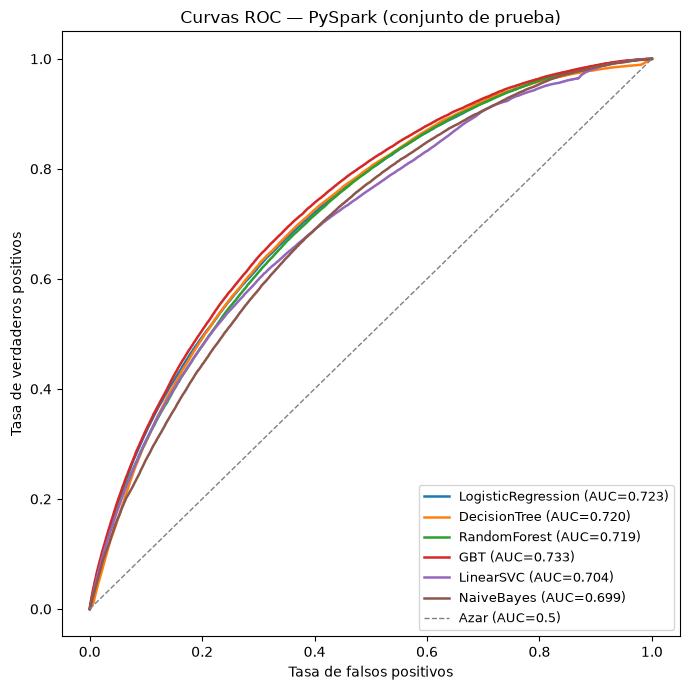

In [3]:
score_cols_spark = {
    "LogisticRegression": "score_LogisticRegression",
    "DecisionTree": "score_DecisionTree",
    "RandomForest": "score_RandomForest",
    "GBT": "score_GBT",
    "LinearSVC": "score_LinearSVC",
    "NaiveBayes": "score_NaiveBayes",
}

fig, ax = plt.subplots(figsize=(7,7))
for nombre, col in score_cols_spark.items():
    fpr, tpr, _ = roc_curve(y_test, scores_spark[col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.3f})", linewidth=1.8)
ax.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — PySpark (conjunto de prueba)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/roc_spark.png", dpi=110)
plt.show()


## 4.5. Matrices de confusión (umbral natural: 0,5 de probabilidad, o margen 0)

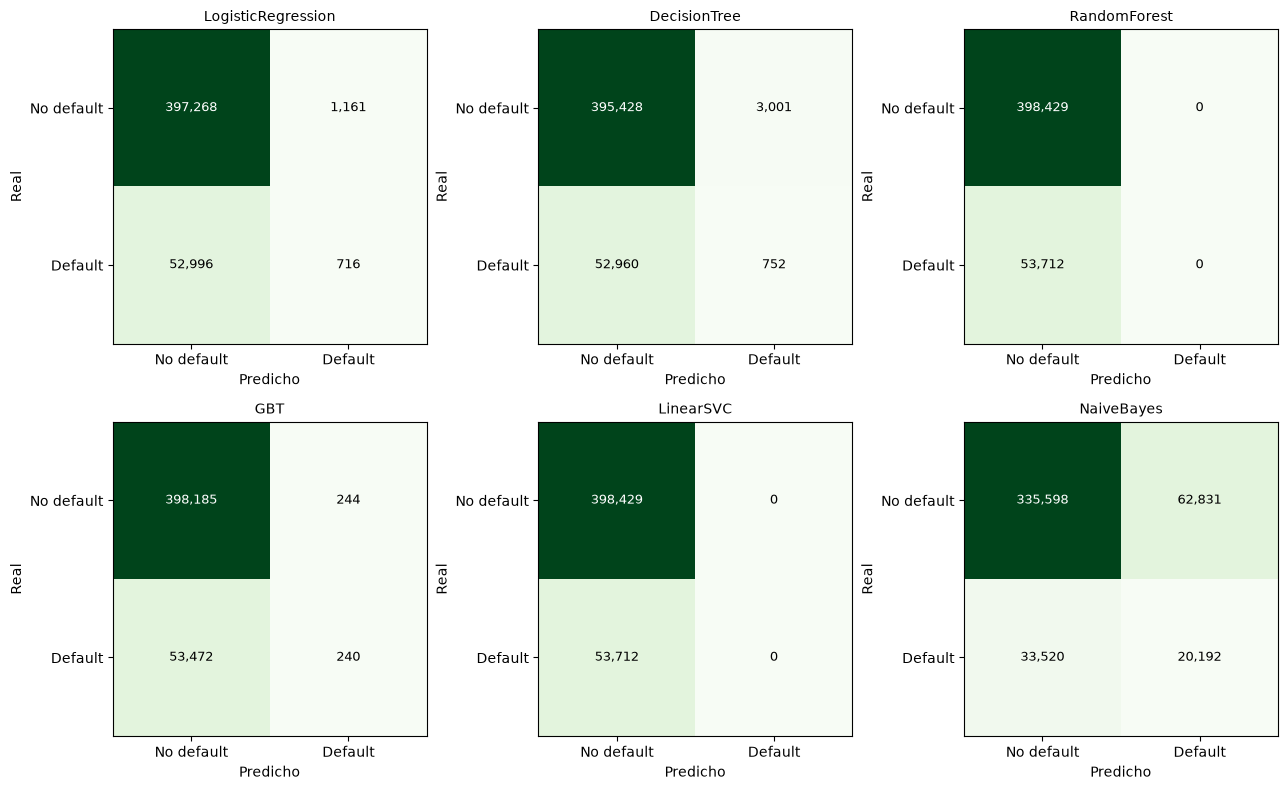

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13,8))
for ax, (nombre, col) in zip(axes.flat, score_cols_spark.items()):
    if nombre == "LinearSVC":
        y_pred = (scores_spark[col] >= 0).astype(int)
    else:
        y_pred = (scores_spark[col] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Greens")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
    ax.set_xticks([0,1]); ax.set_xticklabels(["No default","Default"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["No default","Default"])
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/confusion_spark.png", dpi=110)
plt.show()


## 4.6. Tres hallazgos que solo aparecen al comparar con scikit-learn

### (a) El árbol de decisión sigue rindiendo algo peor en Spark, incluso ya corregido (AUC 0,720 contra 0,737)

Después de corregir el error de la sección 4.2.2 (usar `probability` en vez de `rawPrediction`), la diferencia se reduce bastante, de 14 puntos de AUC a menos de 2, y además cada entorno elige una profundidad distinta como la mejor (`maxDepth=15` en Spark, `maxDepth=10` en scikit-learn). Esto nos dice que las dos implementaciones no son idénticas. Lo que queda de diferencia probablemente viene de `maxBins` (32 por defecto en `DecisionTreeClassifier` de Spark): las variables continuas se discretizan en como máximo 32 puntos de corte candidatos antes de buscar la mejor división, mientras que scikit-learn evalúa cualquier punto de corte real entre valores consecutivos. A diferencia de lo que pensamos al principio, esto ya no explica una brecha grande, porque la mayor parte de la diferencia que veíamos al inicio era en realidad el error de la columna de puntaje, no una diferencia real entre algoritmos.

### (b) `LinearSVC` no colapsa en Spark (AUC 0,704 contra 0,559 en scikit-learn)

Los dos entornos usan pérdida hinge y una malla de regularización equivalente, pero scikit-learn escogió la regularización más fuerte disponible en su malla (la misma que, según vimos en el diagnóstico de la sección 3.7, empuja al modelo a colapsar hacia \"no default\" para todo el mundo), mientras que Spark escogió la regularización más débil de la misma malla, y sus puntajes mantienen una dispersión real en vez de quedar casi constantes. Esto sugiere que el optimizador de Spark (OWL-QN) recorre la superficie de pérdida de forma distinta al `liblinear` de scikit-learn, y para este problema tan desbalanceado, no queda atrapado en la misma solución degenerada. Vale la pena aclarar que, al umbral natural (margen=0), los dos entornos igual predicen 0 casos positivos. La diferencia real está en la calidad del ranking que mide el AUC, no en el comportamiento a ese umbral por defecto.

In [5]:
print("scikit-learn LinearSVC — mejor C:", results_sklearn.loc[results_sklearn.modelo=='LinearSVC','best_params'].values[0])
print("PySpark      LinearSVC — mejor regParam:", results_spark.loc[results_spark.modelo=='LinearSVC','best_params'].values[0])
print()
print("scikit-learn LinearSVC — score en prueba: min=%.4f max=%.4f std=%.6f" % (
    scores_sklearn['score_LinearSVC'].min(), scores_sklearn['score_LinearSVC'].max(), scores_sklearn['score_LinearSVC'].std()))
print("PySpark      LinearSVC — score en prueba: min=%.4f max=%.4f std=%.6f" % (
    scores_spark['score_LinearSVC'].min(), scores_spark['score_LinearSVC'].max(), scores_spark['score_LinearSVC'].std()))


scikit-learn LinearSVC — mejor C: {"C": 0.05529260848409784}
PySpark      LinearSVC — mejor regParam: {"regParam": 1e-06}

scikit-learn LinearSVC — score en prueba: min=-1.0000 max=-1.0000 std=0.000000
PySpark      LinearSVC — score en prueba: min=-1.3426 max=-0.9977 std=0.058776


### (c) Naive Bayes: el mismo error que en (a), no una diferencia real entre librerías

En la primera versión de esta sección, Naive Bayes de Spark aparecía muy por debajo de scikit-learn (AUC 0,564 contra 0,694), y en un primer momento pensamos que se debía a diferencias en cómo cada librería suaviza la varianza. Esa comparación estaba mal por la misma razón que el árbol de decisión en (a): `NaiveBayesModel` no tiene hiperparámetros que ajustar, pero el AUC que reportábamos igual se calculó con la columna `rawPrediction`, mientras que el puntaje que realmente guardamos y usamos en la matriz de confusión viene de la columna `probability`. Para este modelo esas dos columnas tampoco son equivalentes en cuanto al orden que producen. Al recalcular con el evaluador correcto (`src/fix_naivebayes_spark.py`):

```
cv_auc:   0.5644  ->  0.6998\ntest_auc: 0.5643  ->  0.6989
```

Con el número correcto, Naive Bayes en Spark queda prácticamente empatado con `GaussianNB` de scikit-learn (0,699 contra 0,694). No hay ninguna diferencia real de implementación que explicar aquí. La lección se repite y se refuerza: conviene revisar, modelo por modelo, que la columna de puntaje que se usa para evaluar coincide con la que realmente se usa en el resto del pipeline, en vez de asumirlo según el tipo de modelo.

## 4.7. Costo computacional: scikit-learn contra PySpark, modelo por modelo

In [6]:
comparacion_tiempo = results_sklearn[["modelo","tiempo_entrenamiento_s","test_auc"]].rename(
    columns={"tiempo_entrenamiento_s":"tiempo_sklearn_s","test_auc":"auc_sklearn"})
mapa_nombres = {"GBT_HistGB": "GBT"}  # normalizar nombre para el cruce
tmp = results_spark[["modelo","tiempo_entrenamiento_s","test_auc"]].rename(
    columns={"tiempo_entrenamiento_s":"tiempo_spark_s","test_auc":"auc_spark"})
comparacion_tiempo["modelo_join"] = comparacion_tiempo["modelo"].replace(mapa_nombres)
comparacion_tiempo = comparacion_tiempo.merge(tmp, left_on="modelo_join", right_on="modelo", suffixes=("","_2"))
comparacion_tiempo["mas_rapido"] = np.where(comparacion_tiempo["tiempo_sklearn_s"] < comparacion_tiempo["tiempo_spark_s"],
                                              "scikit-learn", "PySpark")
comparacion_tiempo["razon_veces"] = (comparacion_tiempo[["tiempo_sklearn_s","tiempo_spark_s"]].max(axis=1) /
                                      comparacion_tiempo[["tiempo_sklearn_s","tiempo_spark_s"]].min(axis=1))
tabla_final = comparacion_tiempo[["modelo","tiempo_sklearn_s","tiempo_spark_s","mas_rapido","razon_veces","auc_sklearn","auc_spark"]]
tabla_final.round(2)


,modelo,tiempo_sklearn_s,tiempo_spark_s,mas_rapido,razon_veces,auc_sklearn,auc_spark
0,LogisticRegression,70.44,274.68,scikit-learn,3.90,0.72,0.72
1,DecisionTree,509.06,255.74,PySpark,1.99,0.74,0.72
2,RandomForest,6739.25,10597.08,scikit-learn,1.57,0.72,0.72
3,GBT_HistGB,600.44,2950.21,scikit-learn,4.91,0.74,0.73
4,LinearSVC,4838.67,567.44,PySpark,8.53,0.56,0.70


In [7]:
total_sklearn = results_sklearn["tiempo_entrenamiento_s"].sum()
total_spark = results_spark["tiempo_entrenamiento_s"].sum()
print(f"Tiempo TOTAL de entrenamiento (6 modelos): scikit-learn={total_sklearn:,.1f}s (~{total_sklearn/60:.1f} min) "
      f"| PySpark={total_spark:,.1f}s (~{total_spark/60:.1f} min)")
print(f"scikit-learn fue {total_spark/total_sklearn:.2f}x mas rapido en total.")


Tiempo TOTAL de entrenamiento (6 modelos): scikit-learn=12,761.4s (~212.7 min) | PySpark=14,694.3s (~244.9 min)
scikit-learn fue 1.15x mas rapido en total.


scikit-learn resultó más rápido en el total (unas 3 horas 33 minutos contra 4 horas 4 minutos), y gana claramente en 4 de los 6 modelos individuales (regresión logística, bosque aleatorio, boosting y Naive Bayes). Esto tiene sentido en una máquina de solo 2 núcleos: el paralelismo distribuido de Spark no tiene margen para compensar su propio costo fijo de coordinación, que se amortiza mejor en un clúster real con muchos más núcleos. `LinearSVC` es la única excepción clara: ahí Spark fue 8,5 veces más rápido y con mejor AUC, pero principalmente porque en scikit-learn ese modelo colapsó a una solución degenerada que, aun así, seguía siendo cara de calcular. `DecisionTree`, ya con el error de la sección 4.2.2 corregido, también fue cerca de 2 veces más rápido en Spark, con un AUC apenas 1,7 puntos por debajo del de scikit-learn. Esta sí es una ventaja razonablemente limpia para Spark, aunque bastante más modesta que la de `LinearSVC`.

Esto responde directamente a una de las preguntas que nos hacíamos al principio: con este hardware, PySpark no llegó a superar a scikit-learn en velocidad total en este proyecto. La ventaja de Spark aparecería con datasets mucho más grandes, que no entren en la memoria de una sola máquina, o con un clúster de varios nodos donde sí haya paralelismo real que aprovechar.

## 4.8. Síntesis: mejor modelo del entorno PySpark

Por AUC de prueba, `GBTClassifier` (0,733) es el mejor modelo de este entorno, igual que en scikit-learn: un método de boosting con histogramas es el que mejor equilibra desempeño y costo. Este modelo (guardado en `data/spark_best_model_GBT`) es el que usamos más adelante para la interpretabilidad con LIME, y los puntajes de los 6 modelos en `data/spark_test_scores.parquet`, calculados sobre exactamente las mismas 452.141 filas de prueba que en scikit-learn, son la base de las comparaciones estadísticas de las secciones 5 y 6.